<a href="https://colab.research.google.com/github/CarlosLeonardo29/pokerhands_mlp/blob/main/A1_3_MLP_Poker_Hands.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning - Algoritmos de Otimização em Perceptrons Multicamadas

### Autor: Carlos Leonardo Lazzari

## Poker Hands

O dataset escolhido consiste em registros de mãos de pôquer, cada uma composta por cinco cartas extraídas de um baralho padrão de 52 cartas. Cada carta é descrita por dois atributos: naipes (suit) e valores (rank), totalizando 10 atributos preditivos (2 atributos para cada uma das 5 cartas). O objetivo deste estudo é prever a classificação das mãos de pôquer com base nas cartas apresentadas. O dataset possui 1.025.010 de instâncias.

Este dataset foi retirado do **UCI Machine Learning Repository**, que é uma fonte reconhecida e amplamente utilizada para a pesquisa e desenvolvimento em aprendizado de máquina, oferecendo uma variedade de conjuntos de dados para diversas aplicações.

1) **S1 - "Naipe da carta #1"**  
   Ordinal (1-4) representando {Copas, Espadas, Ouros, Paus}

2) **C1 - "Valor da carta #1"**  
   Numérico (1-13) representando {Ás, 2, 3, ..., Dama, Rei}

3) **S2 - "Naipe da carta #2"**  
   Ordinal (1-4) representando {Copas, Espadas, Ouros, Paus}

4) **C2 - "Valor da carta #2"**  
   Numérico (1-13) representando {Ás, 2, 3, ..., Dama, Rei}

5) **S3 - "Naipe da carta #3"**  
   Ordinal (1-4) representando {Copas, Espadas, Ouros, Paus}

6) **C3 - "Valor da carta #3"**  
   Numérico (1-13) representando {Ás, 2, 3, ..., Dama, Rei}

7) **S4 - "Naipe da carta #4"**  
   Ordinal (1-4) representando {Copas, Espadas, Ouros, Paus}

8) **C4 - "Valor da carta #4"**  
   Numérico (1-13) representando {Ás, 2, 3, ..., Dama, Rei}

9) **S5 - "Naipe da carta #5"**  
   Ordinal (1-4) representando {Copas, Espadas, Ouros, Paus}

10) **C5 - "Valor da carta #5"**  
    Numérico (1-13) representando {Ás, 2, 3, ..., Dama, Rei}

11) **CLASS - "Mão de Pôquer"**  
    Ordinal (0-9)

    0: Nada na mão; não é uma mão de pôquer reconhecida  
    1: Um par; um par de valores iguais entre cinco cartas  
    2: Dois pares; dois pares de valores iguais entre cinco cartas  
    3: Trinca; três valores iguais entre cinco cartas  
    4: Sequência; cinco cartas com valores consecutivos sem lacunas  
    5: Flush; cinco cartas do mesmo naipe  
    6: Full house; um par + uma trinca de valores diferentes  
    7: Quadra; quatro cartas com valores iguais entre cinco cartas  
    8: Straight flush; sequência + flush  
    9: Royal flush; {Ás, Rei, Dama, Valete, Dez} + flush

Nesta implementação, o modelo de MLP será treinado para reconhecer diferentes padrões de mãos de pôquer a partir dos atributos das cartas, com o objetivo de maximizar a precisão na classificação. Este processo envolve a definição de uma arquitetura de rede com pelo menos uma camada oculta e funções de ativação apropriadas, seguido de seu treinamento e avaliação sobre o dataset fornecido.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix

from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
poker_hand = fetch_ucirepo(id=158)

# data (as pandas dataframes)
X = poker_hand.data.features
y = poker_hand.data.targets

# metadata
print(poker_hand.metadata)

# variable information
print(poker_hand.variables)


{'uci_id': 158, 'name': 'Poker Hand', 'repository_url': 'https://archive.ics.uci.edu/dataset/158/poker+hand', 'data_url': 'https://archive.ics.uci.edu/static/public/158/data.csv', 'abstract': 'Purpose is to predict poker hands', 'area': 'Games', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 1025010, 'num_features': 10, 'feature_types': ['Categorical', 'Integer'], 'demographics': [], 'target_col': ['CLASS'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2002, 'last_updated': 'Sat Mar 09 2024', 'dataset_doi': '10.24432/C5KW38', 'creators': ['Robert Cattral', 'Franz Oppacher'], 'intro_paper': None, 'additional_info': {'summary': 'Each record is an example of a hand consisting of five playing cards drawn from a standard deck of 52. Each card is described using two attributes (suit and rank), for a total of 10 predictive attributes. There is one Class attribute that describes the "Poker Hand". T

In [ ]:
X.head(10)

,S1,C1,S2,C2,S3,C3,S4,C4,S5,C5
0,1,10,1,11,1,13,1,12,1,1
1,2,11,2,13,2,10,2,12,2,1
2,3,12,3,11,3,13,3,10,3,1
3,4,10,4,11,4,1,4,13,4,12
4,4,1,4,13,4,12,4,11,4,10
5,1,2,1,4,1,5,1,3,1,6
6,1,9,1,12,1,10,1,11,1,13
7,2,1,2,2,2,3,2,4,2,5
8,3,5,3,6,3,9,3,7,3,8
9,4,1,4,4,4,2,4,3,4,5


In [ ]:
y.head(10)

,CLASS
0,9
1,9
2,9
3,9
4,9
5,8
6,8
7,8
8,8
9,8


In [ ]:
# Supondo que X e y sejam DataFrames
poker_data = pd.concat([X, y], axis=1)

In [ ]:
poker_data.head()

,S1,C1,S2,C2,S3,C3,S4,C4,S5,C5,CLASS
0,1,10,1,11,1,13,1,12,1,1,9
1,2,11,2,13,2,10,2,12,2,1,9
2,3,12,3,11,3,13,3,10,3,1,9
3,4,10,4,11,4,1,4,13,4,12,9
4,4,1,4,13,4,12,4,11,4,10,9


In [ ]:
# Codificação one-hot para as classes (0 a 9, representando as categorias das mãos)
encoder = OneHotEncoder(sparse_output=False)  # Atualizado de 'sparse' para 'sparse_output'
y_onehot = encoder.fit_transform(y.values.reshape(-1, 1))

In [ ]:
# Dividir em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.3, random_state=42)

In [ ]:
print("Descrição dos dados de treino:")
print(X_train.describe())
print("\nDescrição dos rótulos de treino:")
print(pd.DataFrame(y_train).describe())

print("\nDescrição dos dados de teste:")
print(X_test.describe())
print("\nDescrição dos rótulos de teste:")
print(pd.DataFrame(y_test).describe())


Descrição dos dados de treino:
                  S1             C1             S2             C2  \
count  717507.000000  717507.000000  717507.000000  717507.000000   
mean        2.501378       6.995186       2.499266       7.006732   
std         1.117846       3.742341       1.118683       3.743750   
min         1.000000       1.000000       1.000000       1.000000   
25%         2.000000       4.000000       1.000000       4.000000   
50%         3.000000       7.000000       2.000000       7.000000   
75%         4.000000      10.000000       4.000000      10.000000   
max         4.000000      13.000000       4.000000      13.000000   

                  S3             C3             S4             C4  \
count  717507.000000  717507.000000  717507.000000  717507.000000   
mean        2.500790       6.999454       2.499676       6.997302   
std         1.118651       3.741617       1.117054       3.740356   
min         1.000000       1.000000       1.000000       1.000000   
25

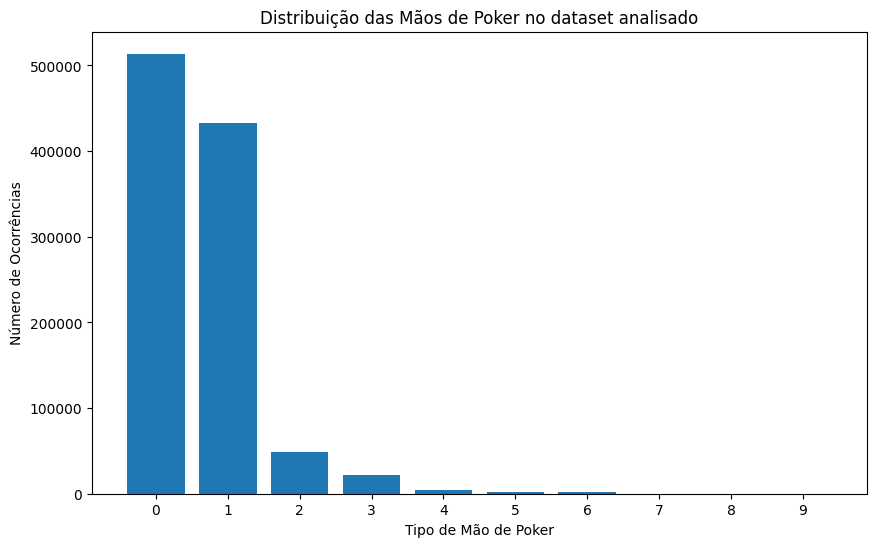

In [ ]:
# Contagem das ocorrências de cada tipo de mão de poker
hand_counts = y['CLASS'].value_counts()

# Criando o gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(hand_counts.index, hand_counts.values)
plt.xlabel('Tipo de Mão de Poker')
plt.ylabel('Número de Ocorrências')
plt.title('Distribuição das Mãos de Poker no dataset analisado')
plt.xticks(hand_counts.index)
plt.show()


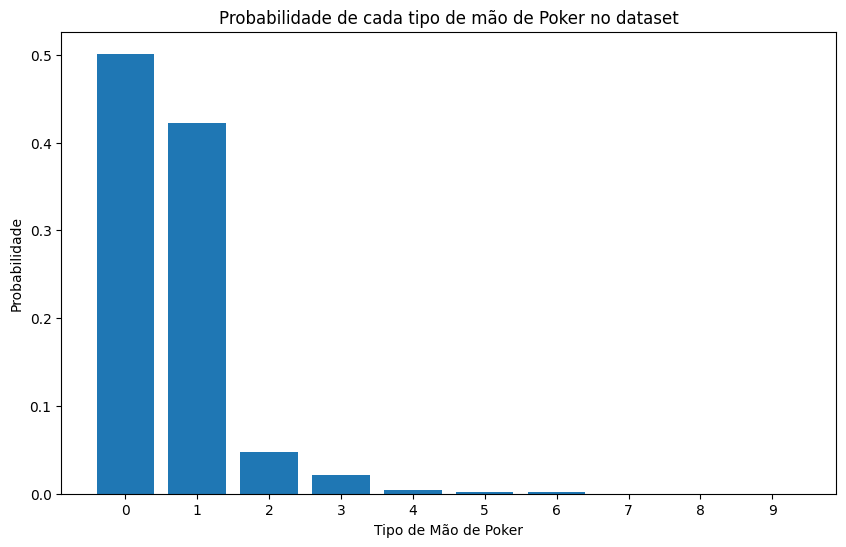

In [ ]:
# Calcular a probabilidade de cada tipo de mão
hand_probabilities = y['CLASS'].value_counts(normalize=True)

# Criar o gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(hand_probabilities.index, hand_probabilities.values)
plt.xlabel('Tipo de Mão de Poker')
plt.ylabel('Probabilidade')
plt.title('Probabilidade de cada tipo de mão de Poker no dataset')
plt.xticks(hand_probabilities.index)
plt.show()


## Arquitetura do Modelo MLP (Perceptron Multicamadas)

A arquitetura do MLP (Perceptron Multicamadas) definido pelo código é composta por três camadas principais, com o objetivo de classificar dados em 10 categorias. A seguir está uma descrição detalhada de cada componente da arquitetura:

### 1. **Camada de Entrada**:
- A camada de entrada é definida implicitamente pelo argumento `input_shape=(X_train.shape[1],)` na primeira camada densa.
- O número de entradas é igual ao número de características das amostras no conjunto de dados (definido por `X_train.shape[1]`).

### 2. **Primeira Camada Oculta**:
- Esta é uma camada totalmente conectada (dense), com **128 neurônios**.
- Função de ativação: **ReLU (Rectified Linear Unit)**.
- Como camada oculta, seu objetivo é capturar padrões e interações complexas entre as características de entrada.

### 3. **Segunda Camada Oculta**:
- Outra camada totalmente conectada com **64 neurônios**.
- Função de ativação: **ReLU**, similar à primeira camada oculta.
- Reduz o número de neurônios comparado à primeira camada, concentrando as características mais importantes aprendidas.

### 4. **Camada de Saída**:
- A última camada é uma camada densa com **10 neurônios**, correspondendo às **10 classes de saída** do problema (categorias de mãos de pôquer).
- Função de ativação: **Softmax**, que transforma a saída em uma distribuição de probabilidade sobre as 10 classes. Cada valor representa a probabilidade da amostra pertencer a uma das categorias.

### 5. **Função de Perda e Otimização**:
- A função de perda é a **categorical_crossentropy**, que mede a diferença entre as previsões do modelo e as classes reais.
- O otimizador pode ser configurado pelo parâmetro `optimizer`, permitindo testar diferentes estratégias de treinamento (como Adam, RMSprop, etc.).
- A métrica de desempenho usada para avaliar o modelo durante o treinamento e teste é a **acurácia**.

### Resumo:
- **Entrada**: Número de características do conjunto de dados.
- **Primeira camada oculta**: 128 neurônios, ativação ReLU.
- **Segunda camada oculta**: 64 neurônios, ativação ReLU.
- **Saída**: 10 neurônios, ativação Softmax (10 classes).
- **Função de perda**: Categorical Crossentropy.
- **Otimização**: Variável, conforme o otimizador passado como argumento.

Essa arquitetura é típica para problemas de classificação multiclasses, e o número de neurônios nas camadas ocultas foi escolhido para garantir que o modelo seja suficientemente expressivo para capturar padrões nos dados.


In [ ]:
def create_model(optimizer):
    model = tf.keras.models.Sequential([
        tf.keras.layers.Dense(128, input_shape=(X_train.shape[1],), activation='relu'),  # Primeira camada oculta
        tf.keras.layers.Dense(64, activation='relu'),  # Segunda camada oculta
        tf.keras.layers.Dense(10, activation='softmax')  # Camada de saída
    ])

    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',  # Para classificação multiclasse
                  metrics=['accuracy'])
    return model

In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

## Algoritmos de Otimização

In [ ]:
optimizers = {
    'Gradient Descent (GD)': tf.keras.optimizers.SGD(learning_rate=0.01),
    'Stochastic Gradient Descent (SGD)': tf.keras.optimizers.SGD(learning_rate=0.01),
    'Adam': tf.keras.optimizers.Adam(learning_rate=0.001),
    'RMSprop': tf.keras.optimizers.RMSprop(learning_rate=0.001),
    'Adagrad': tf.keras.optimizers.Adagrad(learning_rate=0.01)
}

In [ ]:
# Inicializar o dicionário para armazenar previsões
predictions = {}

### Gradient Descent (GD)

O **Gradient Descent** (Descida do Gradiente) é um algoritmo de otimização que atualiza os pesos do modelo na direção do gradiente negativo da função de perda. O objetivo é minimizar essa função utilizando todo o conjunto de dados para calcular o gradiente em cada etapa.

- **Vantagens**:
  - Converge para o mínimo global em funções convexas.

- **Desvantagens**:
  - Pode ser computacionalmente caro para grandes datasets, pois requer o cálculo do gradiente em todo o conjunto de dados.


In [ ]:
# Definindo o otimizador Gradient Descent (GD)
optimizer_gd = tf.keras.optimizers.SGD(learning_rate=0.05)

# Criar o modelo com Gradient Descent
model_gd = create_model(optimizer=optimizer_gd)

# Treinamento do modelo
history_gd = model_gd.fit(X_train, y_train, epochs=16, verbose=1, validation_split=0.2)

# Avaliar o modelo no conjunto de teste
loss_gd, accuracy_gd = model_gd.evaluate(X_test, y_test, verbose=0)
print(f"Gradient Descent (GD) - Acurácia no Teste: {accuracy_gd:.4f}, Perda no Teste: {loss_gd:.4f}")

# Fazendo previsões e armazenando no dicionário
y_pred_gd = np.argmax(model_gd.predict(X_test), axis=1)
predictions['Gradient Descent (GD)'] = y_pred_gd

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/16
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 48s 3ms/step - accuracy: 0.5388 - loss: 0.9583 - val_accuracy: 0.6173 - val_loss: 0.8483
Epoch 2/16
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 32s 2ms/step - accuracy: 0.6475 - loss: 0.8084 - val_accuracy: 0.6968 - val_loss: 0.8460
Epoch 3/16
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 46s 2ms/step - accuracy: 0.7902 - loss: 0.5746 - val_accuracy: 0.9174 - val_loss: 0.2404
Epoch 4/16
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 32s 2ms/step - accuracy: 0.8670 - loss: 0.3982 - val_accuracy: 0.8867 - val_loss: 0.3555
Epoch 5/16
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - accuracy: 0.8951 - loss: 0.3186 - val_accuracy: 0.9895 - val_loss: 0.0558
Epoch 6/16
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - accuracy: 0.9290 - loss: 0.2318 - val_accuracy: 0.5316 - val_loss: 1.8087
Epoch 7/16
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - accuracy: 0.9239 - loss: 0.2365 - val_accuracy: 0.9821 - val_loss: 0.0948
Epoch 8/16
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - accuracy: 

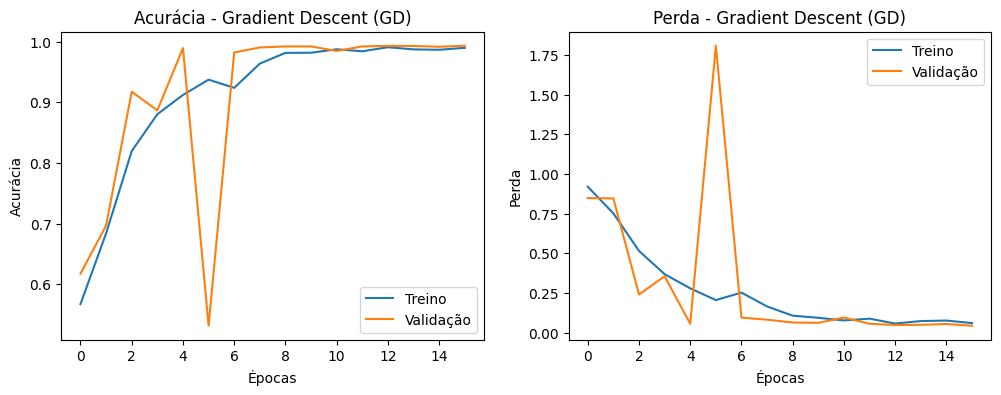

In [ ]:
# Função para plotar a história de treinamento
def plot_history(history, optimizer_name):
    plt.figure(figsize=(12, 4))

    # Plotar Acurácia
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Treino')
    plt.plot(history.history['val_accuracy'], label='Validação')
    plt.title(f'Acurácia - {optimizer_name}')
    plt.xlabel('Épocas')
    plt.ylabel('Acurácia')
    plt.legend()

    # Plotar Perda
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Treino')
    plt.plot(history.history['val_loss'], label='Validação')
    plt.title(f'Perda - {optimizer_name}')
    plt.xlabel('Épocas')
    plt.ylabel('Perda')
    plt.legend()

    plt.show()

plot_history(history_gd, "Gradient Descent (GD)")

In [ ]:
model_gd.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_61 (Dense)                     │ (None, 128)                 │           1,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_62 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_63 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,316 (40.30 KB)

 Trainable params: 10,314 (40.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

### Stochastic Gradient Descent (SGD)

O **Stochastic Gradient Descent** (Descida do Gradiente Estocástica) é uma variante do Gradient Descent que usa apenas um exemplo de treinamento (ou um pequeno lote de exemplos) para atualizar os pesos em cada iteração. Isso torna o processo mais rápido e eficiente.

- **Vantagens**:
  - Atualizações mais rápidas e a capacidade de escapar de mínimos locais.

- **Desvantagens**:
  - Pode ser instável e oscilar em torno do mínimo.


In [ ]:
# Definindo o otimizador Stochastic Gradient Descent (SGD)
optimizer_sgd = tf.keras.optimizers.SGD(learning_rate=0.01)

# Criar o modelo com Stochastic Gradient Descent
model_sgd = create_model(optimizer=optimizer_sgd)

# Treinamento do modelo
history_sgd = model_sgd.fit(X_train, y_train, epochs=16, verbose=1, validation_split=0.2)

# Avaliar o modelo no conjunto de teste
loss_sgd, accuracy_sgd = model_sgd.evaluate(X_test, y_test, verbose=0)
print(f"Stochastic Gradient Descent (SGD) - Acurácia no Teste: {accuracy_sgd:.4f}, Perda no Teste: {loss_sgd:.4f}")

# Fazendo previsões e armazenando no dicionário
y_pred_sgd = np.argmax(model_sgd.predict(X_test), axis=1)
predictions['Stochastic Gradient Descent (SGD)'] = y_pred_sgd

Epoch 1/16


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


17938/17938 ━━━━━━━━━━━━━━━━━━━━ 32s 2ms/step - accuracy: 0.5352 - loss: 0.9701 - val_accuracy: 0.5907 - val_loss: 0.8881
Epoch 2/16
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step - accuracy: 0.6150 - loss: 0.8623 - val_accuracy: 0.6880 - val_loss: 0.7357
Epoch 3/16
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 37s 2ms/step - accuracy: 0.6787 - loss: 0.7460 - val_accuracy: 0.7110 - val_loss: 0.6879
Epoch 4/16
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - accuracy: 0.7263 - loss: 0.6596 - val_accuracy: 0.8260 - val_loss: 0.4647
Epoch 5/16
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 33s 2ms/step - accuracy: 0.7918 - loss: 0.5441 - val_accuracy: 0.8640 - val_loss: 0.3782
Epoch 6/16
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 36s 2ms/step - accuracy: 0.8605 - loss: 0.4217 - val_accuracy: 0.9598 - val_loss: 0.2011
Epoch 7/16
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 31s 2ms/step - accuracy: 0.9217 - loss: 0.2986 - val_accuracy: 0.9758 - val_loss: 0.1288
Epoch 8/16
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 32s 2ms/step - accuracy: 0.9587 - lo

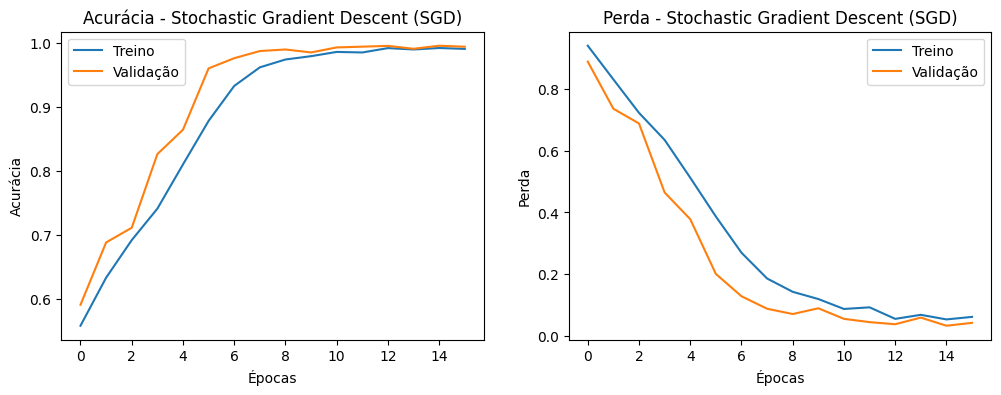

In [ ]:
# Função para plotar a história de treinamento
def plot_history(history, optimizer_name):
    plt.figure(figsize=(12, 4))

    # Plotar Acurácia
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Treino')
    plt.plot(history.history['val_accuracy'], label='Validação')
    plt.title(f'Acurácia - {optimizer_name}')
    plt.xlabel('Épocas')
    plt.ylabel('Acurácia')
    plt.legend()

    # Plotar Perda
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Treino')
    plt.plot(history.history['val_loss'], label='Validação')
    plt.title(f'Perda - {optimizer_name}')
    plt.xlabel('Épocas')
    plt.ylabel('Perda')
    plt.legend()

    plt.show()

plot_history(history_sgd, "Stochastic Gradient Descent (SGD)")

In [ ]:
model_sgd.summary()

Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_64 (Dense)                     │ (None, 128)                 │           1,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_65 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_66 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,316 (40.30 KB)

 Trainable params: 10,314 (40.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

### Adam (Adaptive Moment Estimation)

O **Adam** combina as vantagens do **AdaGrad** e do **RMSprop**, ajustando a taxa de aprendizado de cada parâmetro com base nas médias móveis dos gradientes. É um dos algoritmos de otimização mais utilizados atualmente.

- **Vantagens**:
  - Funciona bem com problemas onde os gradientes têm magnitudes diferentes e tem uma convergência rápida.

- **Desvantagens**:
  - Pode convergir muito rápido para mínimos locais, o que pode ser indesejável em alguns casos.

In [ ]:
# Definindo o otimizador Adam
optimizer_adam = tf.keras.optimizers.Adam(learning_rate=0.003)

# Criar o modelo com Adam
model_adam = create_model(optimizer=optimizer_adam)

# Treinamento do modelo
history_adam = model_adam.fit(X_train, y_train, epochs=16, verbose=1, validation_split=0.2)

# Avaliar o modelo no conjunto de teste
loss_adam, accuracy_adam = model_adam.evaluate(X_test, y_test, verbose=0)
print(f"Adam - Acurácia no Teste: {accuracy_adam:.4f}, Perda no Teste: {loss_adam:.4f}")

# Fazendo previsões e armazenando no dicionário
y_pred_adam = np.argmax(model_adam.predict(X_test), axis=1)
predictions['Adam'] = y_pred_adam

Epoch 1/16


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


17938/17938 ━━━━━━━━━━━━━━━━━━━━ 36s 2ms/step - accuracy: 0.5479 - loss: 0.9518 - val_accuracy: 0.6440 - val_loss: 0.8001
Epoch 2/16
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 37s 2ms/step - accuracy: 0.6673 - loss: 0.7675 - val_accuracy: 0.7369 - val_loss: 0.6518
Epoch 3/16
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - accuracy: 0.7491 - loss: 0.6221 - val_accuracy: 0.8172 - val_loss: 0.4949
Epoch 4/16
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - accuracy: 0.8217 - loss: 0.4832 - val_accuracy: 0.8451 - val_loss: 0.4069
Epoch 5/16
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - accuracy: 0.8441 - loss: 0.4384 - val_accuracy: 0.8453 - val_loss: 0.4621
Epoch 6/16
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - accuracy: 0.8844 - loss: 0.3411 - val_accuracy: 0.9110 - val_loss: 0.2603
Epoch 7/16
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step - accuracy: 0.9021 - loss: 0.2947 - val_accuracy: 0.9204 - val_loss: 0.2294
Epoch 8/16
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/step - accuracy: 0.9137 - lo

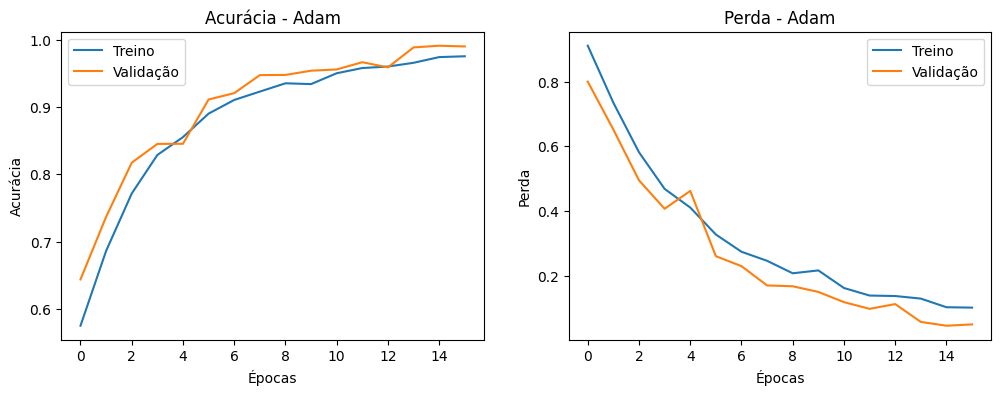

In [ ]:
# Função para plotar a história de treinamento
def plot_history(history, optimizer_name):
    plt.figure(figsize=(12, 4))

    # Plotar Acurácia
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Treino')
    plt.plot(history.history['val_accuracy'], label='Validação')
    plt.title(f'Acurácia - {optimizer_name}')
    plt.xlabel('Épocas')
    plt.ylabel('Acurácia')
    plt.legend()

    # Plotar Perda
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Treino')
    plt.plot(history.history['val_loss'], label='Validação')
    plt.title(f'Perda - {optimizer_name}')
    plt.xlabel('Épocas')
    plt.ylabel('Perda')
    plt.legend()

    plt.show()

plot_history(history_adam, "Adam")

In [ ]:
model_adam.summary()

Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_67 (Dense)                     │ (None, 128)                 │           1,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_68 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_69 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,944 (120.88 KB)

 Trainable params: 10,314 (40.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20,630 (80.59 KB)

### RMSprop (Root Mean Square Propagation)

O **RMSprop** ajusta a taxa de aprendizado de cada parâmetro com base em uma média móvel dos quadrados dos gradientes, sendo especialmente útil para problemas de séries temporais.

- **Vantagens**:
  - Boa escolha para problemas em que os gradientes variam significativamente e funciona bem com gradientes que possuem magnitudes diferentes.

- **Desvantagens**:
  - Pode ter dificuldades em convergir para o mínimo global em alguns casos.

In [ ]:
# Definindo o otimizador RMSprop
optimizer_rmsprop = tf.keras.optimizers.RMSprop(learning_rate=0.005)

# Criar o modelo com RMSprop
model_rmsprop = create_model(optimizer=optimizer_rmsprop)

# Treinamento do modelo
history_rmsprop = model_rmsprop.fit(X_train, y_train, epochs=24, verbose=1, validation_split=0.2)

# Avaliar o modelo no conjunto de teste
loss_rmsprop, accuracy_rmsprop = model_rmsprop.evaluate(X_test, y_test, verbose=0)
print(f"RMSprop - Acurácia no Teste: {accuracy_rmsprop:.4f}, Perda no Teste: {loss_rmsprop:.4f}")

# Fazendo previsões e armazenando no dicionário
y_pred_rmsprop = np.argmax(model_rmsprop.predict(X_test), axis=1)
predictions['RMSprop'] = y_pred_rmsprop

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/24
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 36s 2ms/step - accuracy: 0.5346 - loss: 0.9740 - val_accuracy: 0.5608 - val_loss: 0.9416
Epoch 2/24
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 46s 2ms/step - accuracy: 0.5623 - loss: 0.9408 - val_accuracy: 0.5702 - val_loss: 0.9407
Epoch 3/24
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/step - accuracy: 0.5772 - loss: 0.9226 - val_accuracy: 0.5679 - val_loss: 0.9389
Epoch 4/24
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/step - accuracy: 0.5765 - loss: 0.9228 - val_accuracy: 0.5808 - val_loss: 0.9070
Epoch 5/24
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 45s 2ms/step - accuracy: 0.5788 - loss: 0.9227 - val_accuracy: 0.5731 - val_loss: 0.9187
Epoch 6/24
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 34s 2ms/step - accuracy: 0.5779 - loss: 0.9252 - val_accuracy: 0.5806 - val_loss: 0.9238
Epoch 7/24
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 34s 2ms/step - accuracy: 0.5762 - loss: 0.9257 - val_accuracy: 0.5818 - val_loss: 0.9160
Epoch 8/24
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step - accuracy: 

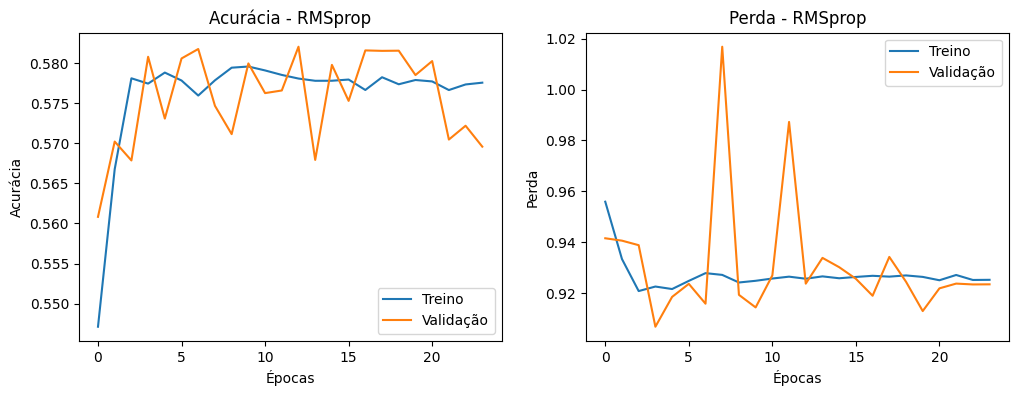

In [ ]:
# Função para plotar a história de treinamento
def plot_history(history, optimizer_name):
    plt.figure(figsize=(12, 4))

    # Plotar Acurácia
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Treino')
    plt.plot(history.history['val_accuracy'], label='Validação')
    plt.title(f'Acurácia - {optimizer_name}')
    plt.xlabel('Épocas')
    plt.ylabel('Acurácia')
    plt.legend()

    # Plotar Perda
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Treino')
    plt.plot(history.history['val_loss'], label='Validação')
    plt.title(f'Perda - {optimizer_name}')
    plt.xlabel('Épocas')
    plt.ylabel('Perda')
    plt.legend()

    plt.show()

plot_history(history_rmsprop, "RMSprop")

In [ ]:
model_rmsprop.summary()

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_70 (Dense)                     │ (None, 128)                 │           1,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_71 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_72 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20,630 (80.59 KB)

 Trainable params: 10,314 (40.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,316 (40.30 KB)

### Adagrad (Adaptive Gradient Algorithm)

O **Adagrad** adapta a taxa de aprendizado de acordo com o histórico acumulado de gradientes, tornando-o útil para problemas com dados esparsos.

- **Vantagens**:
  - Ajuste automático da taxa de aprendizado, especialmente útil em dados esparsos.

- **Desvantagens**:
  - A taxa de aprendizado pode diminuir excessivamente, o que pode impedir a convergência em estágios posteriores do treinamento.

In [ ]:
# Definindo o otimizador Adagrad
optimizer_adagrad = tf.keras.optimizers.Adagrad(learning_rate=0.05)

# Criar o modelo com Adagrad
model_adagrad = create_model(optimizer=optimizer_adagrad)

# Treinamento do modelo
history_adagrad = model_adagrad.fit(X_train, y_train, epochs=16, verbose=1, validation_split=0.2)

# Avaliar o modelo no conjunto de teste
loss_adagrad, accuracy_adagrad = model_adagrad.evaluate(X_test, y_test, verbose=0)
print(f"Adagrad - Acurácia no Teste: {accuracy_adagrad:.4f}, Perda no Teste: {loss_adagrad:.4f}")

# Fazendo previsões e armazenando no dicionário
y_pred_adagrad = np.argmax(model_adagrad.predict(X_test), axis=1)
predictions['Adagrad'] = y_pred_adagrad

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/16
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/step - accuracy: 0.5627 - loss: 0.9311 - val_accuracy: 0.6871 - val_loss: 0.7271
Epoch 2/16
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - accuracy: 0.7409 - loss: 0.6459 - val_accuracy: 0.8601 - val_loss: 0.4429
Epoch 3/16
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 34s 2ms/step - accuracy: 0.8674 - loss: 0.4057 - val_accuracy: 0.9066 - val_loss: 0.2930
Epoch 4/16
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - accuracy: 0.9310 - loss: 0.2666 - val_accuracy: 0.9425 - val_loss: 0.2076
Epoch 5/16
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step - accuracy: 0.9569 - loss: 0.1898 - val_accuracy: 0.9743 - val_loss: 0.1554
Epoch 6/16
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - accuracy: 0.9690 - loss: 0.1486 - val_accuracy: 0.9732 - val_loss: 0.1345
Epoch 7/16
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 36s 2ms/step - accuracy: 0.9757 - loss: 0.1243 - val_accuracy: 0.9816 - val_loss: 0.1056
Epoch 8/16
17938/17938 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - accuracy: 

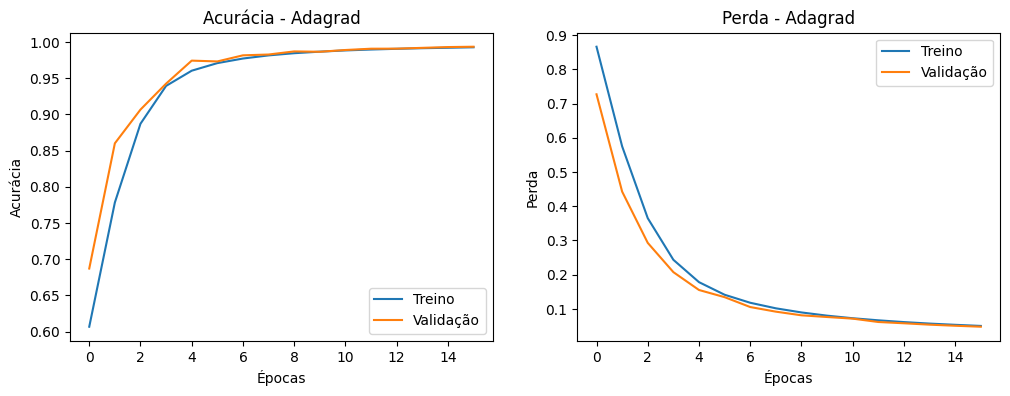

In [ ]:
# Função para plotar a história de treinamento
def plot_history(history, optimizer_name):
    plt.figure(figsize=(12, 4))

    # Plotar Acurácia
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Treino')
    plt.plot(history.history['val_accuracy'], label='Validação')
    plt.title(f'Acurácia - {optimizer_name}')
    plt.xlabel('Épocas')
    plt.ylabel('Acurácia')
    plt.legend()

    # Plotar Perda
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Treino')
    plt.plot(history.history['val_loss'], label='Validação')
    plt.title(f'Perda - {optimizer_name}')
    plt.xlabel('Épocas')
    plt.ylabel('Perda')
    plt.legend()

    plt.show()

plot_history(history_adagrad, "Adagrad")

In [ ]:
model_adagrad.summary()

Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_73 (Dense)                     │ (None, 128)                 │           1,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_74 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_75 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 20,630 (80.59 KB)

 Trainable params: 10,314 (40.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 10,316 (40.30 KB)

## Análise dos Resultados

In [ ]:
results = {
    'Gradient Descent (GD)': history_gd.history,
    'Stochastic Gradient Descent (SGD)': history_sgd.history,
    'Adam': history_adam.history,
    'RMSprop': history_rmsprop.history,
    'Adagrad': history_adagrad.history
}

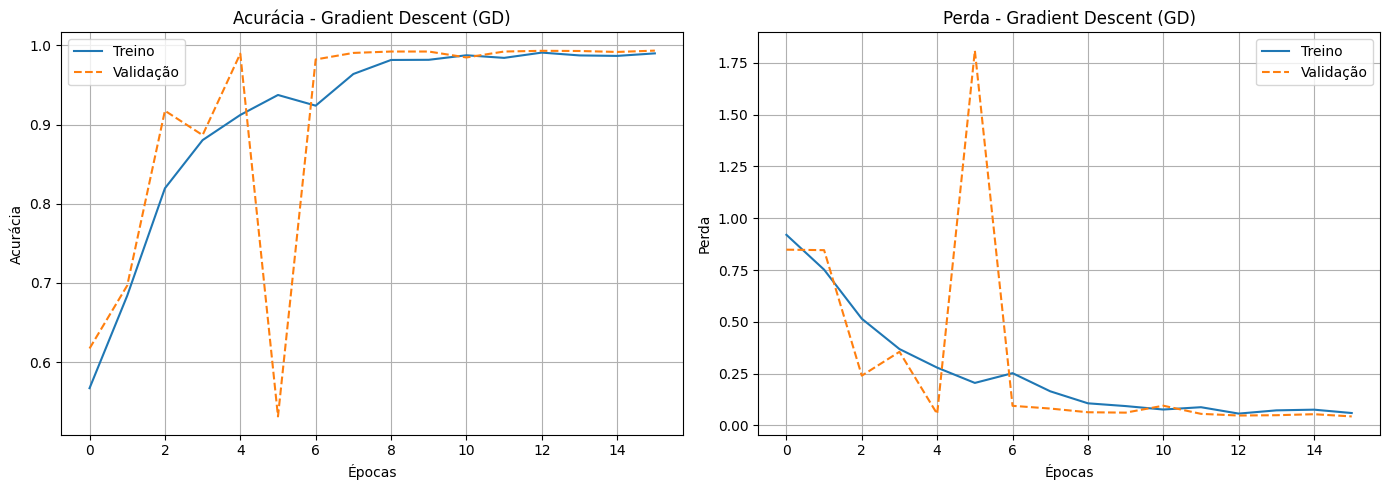

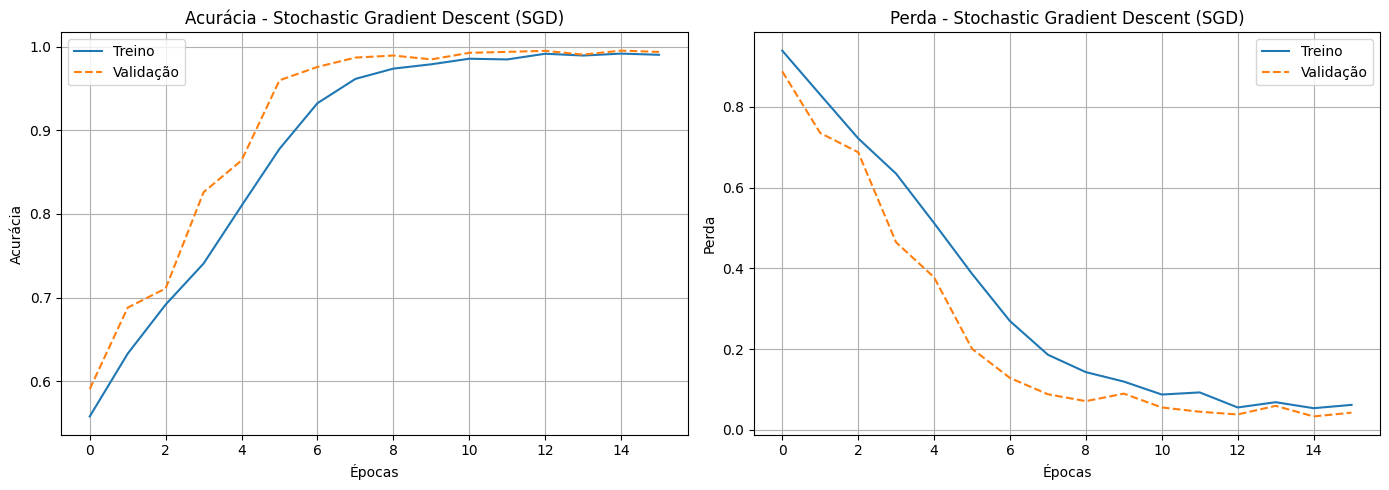

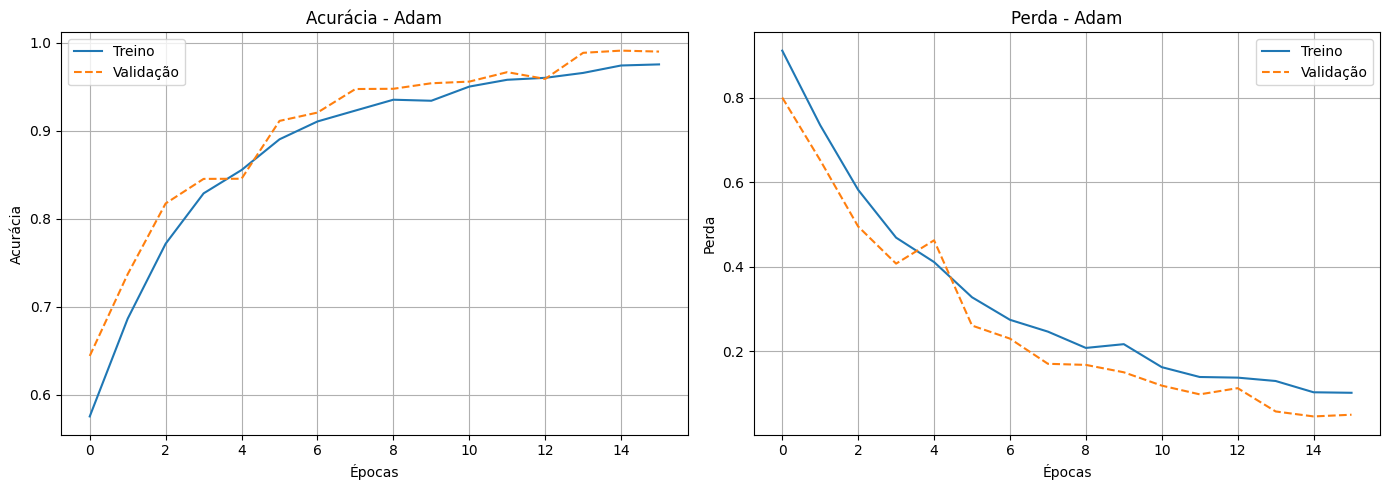

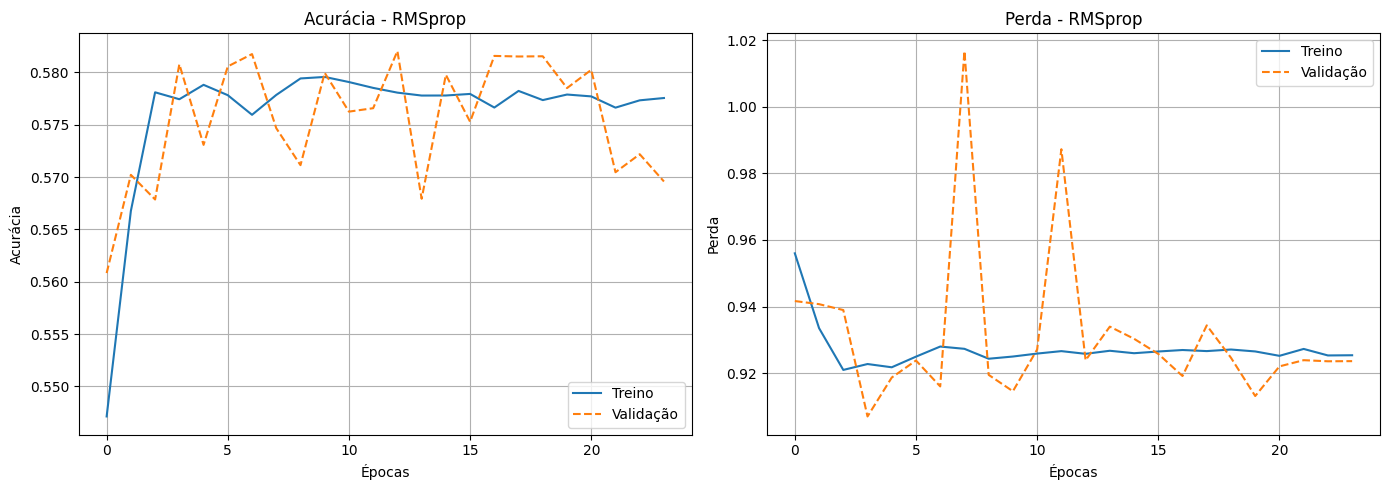

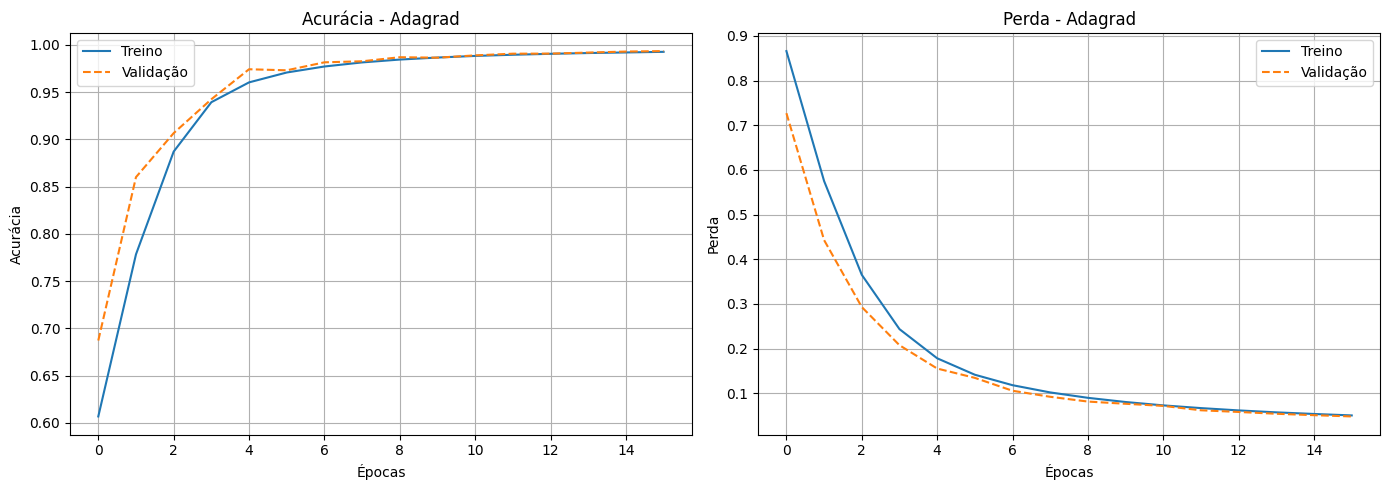

In [ ]:
# Criar gráficos separados para cada otimizador
for opt_name, metrics in results.items():
    plt.figure(figsize=(14, 5))

    # Gráfico de Acurácia
    plt.subplot(1, 2, 1)
    plt.plot(metrics['accuracy'], label='Treino')
    plt.plot(metrics['val_accuracy'], label='Validação', linestyle='--')
    plt.title(f'Acurácia - {opt_name}')
    plt.xlabel('Épocas')
    plt.ylabel('Acurácia')
    plt.legend()
    plt.grid()

    # Gráfico de Perda
    plt.subplot(1, 2, 2)
    plt.plot(metrics['loss'], label='Treino')
    plt.plot(metrics['val_loss'], label='Validação', linestyle='--')
    plt.title(f'Perda - {opt_name}')
    plt.xlabel('Épocas')
    plt.ylabel('Perda')
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

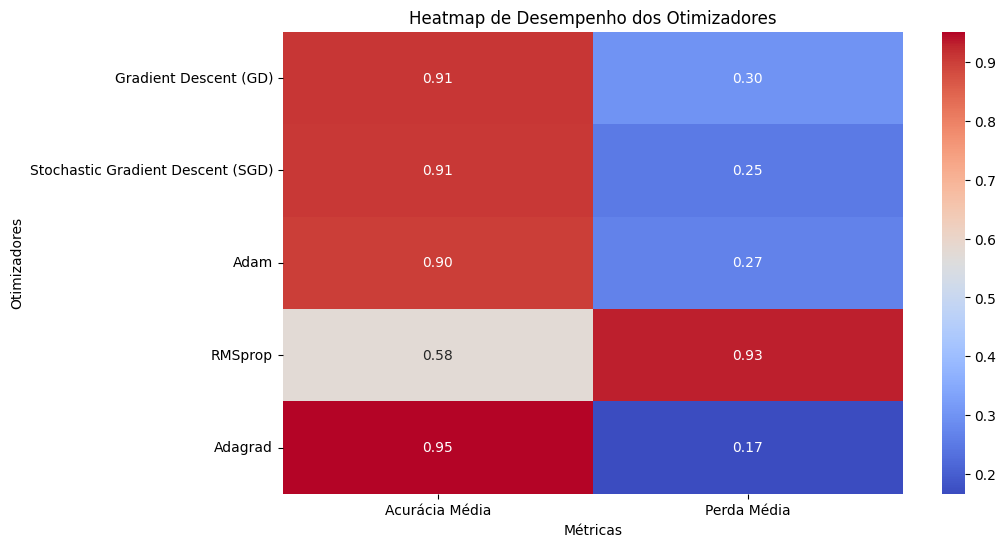

In [ ]:
acuracia_media = []
perda_media = []

# Calcular a média de acurácia e perda para cada otimizador
for opt_name, metrics in results.items():
    acuracia_media.append(np.mean(metrics['val_accuracy']))
    perda_media.append(np.mean(metrics['val_loss']))

# Criar um DataFrame para os resultados
df_resultados = pd.DataFrame({
    'Otimizador': list(results.keys()),
    'Acurácia Média': acuracia_media,
    'Perda Média': perda_media
})

# Criar o heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df_resultados.set_index('Otimizador'), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap de Desempenho dos Otimizadores')
plt.xlabel('Métricas')
plt.ylabel('Otimizadores')
plt.show()

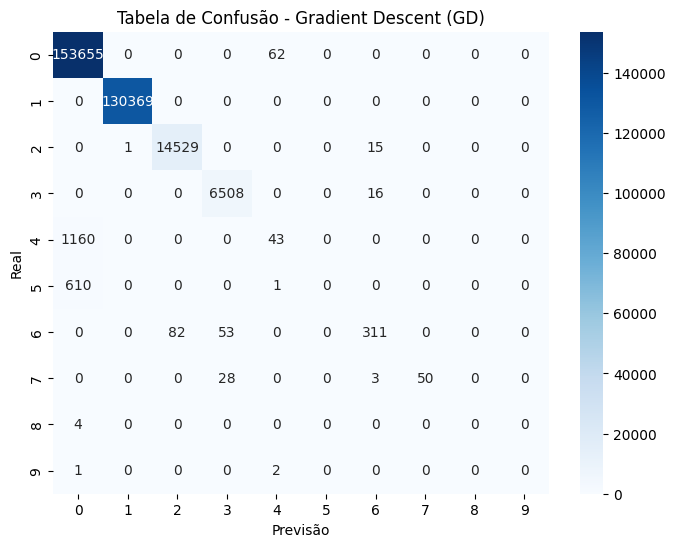

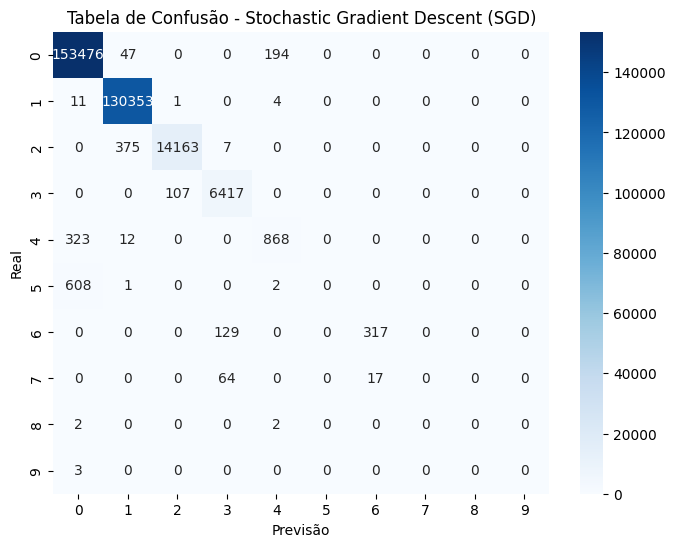

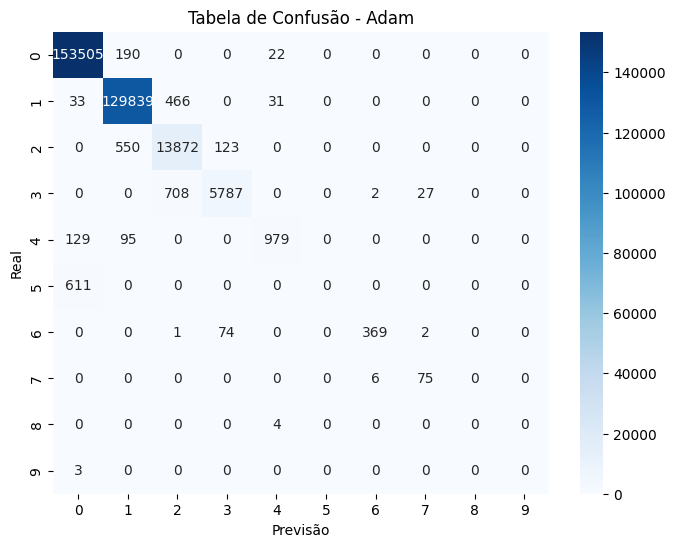

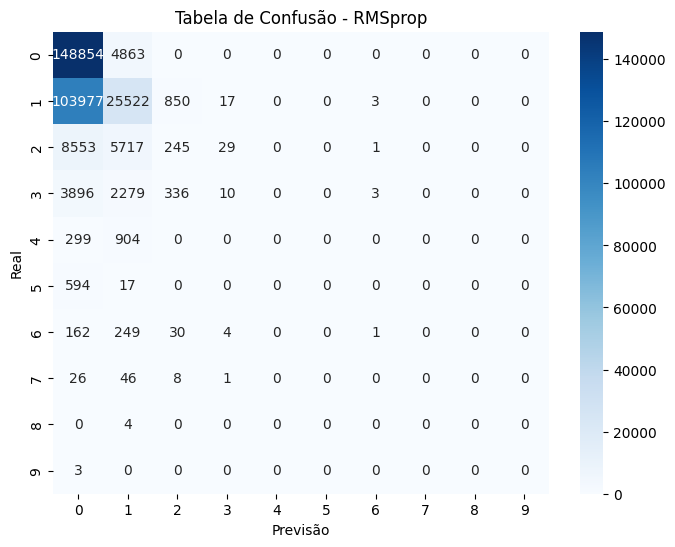

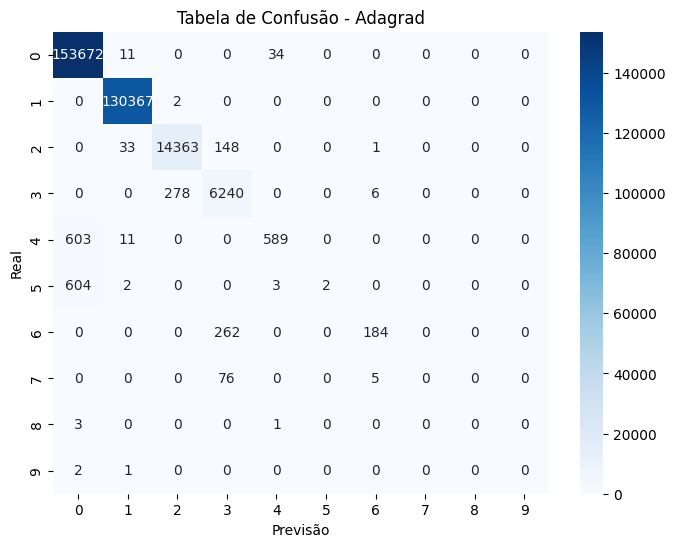

In [ ]:
# Criar tabelas separadas para cada modelo comparando previsões e valores reais
for model, predictions in predictions.items():
    # Criar um DataFrame comparando as previsões do modelo com os valores reais
    comparison_df = pd.DataFrame({
        'Real': y_test_classes,  # Valores reais
        'Previsto': predictions  # Previsões do modelo atual
    })

    # Criar a tabela de confusão para o modelo
    cm = confusion_matrix(comparison_df['Real'], comparison_df['Previsto'])
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.arange(10), yticklabels=np.arange(10))
    plt.title(f'Tabela de Confusão - {model}')
    plt.xlabel('Previsão')
    plt.ylabel('Real')
    plt.show()


## Desempenho dos Algoritmos de Otimização no Dataset Poker Hands

1. **Gradient Descent (GD)**:
   - **Acurácia Média**: **0.91**
   - **Perda Média**: **0.30**
   - **Análise**: O GD apresentou um desempenho razoável, alcançando uma acurácia média de 91%. No entanto, o uso de todo o conjunto de dados em cada iteração torna o processo de treinamento lento e ineficiente. No contexto do dataset Poker Hands, que possui um número elevado de instâncias, isso pode resultar em tempos de treinamento excessivos e potencial overfitting, onde o modelo aprende a memorizar os dados em vez de generalizar.

2. **Stochastic Gradient Descent (SGD)**:
   - **Acurácia Média**: **0.91**
   - **Perda Média**: **0.25**
   - **Análise**: O SGD também alcançou uma acurácia média de 91%, mas com uma perda média mais baixa de 0.25. Essa abordagem é mais rápida, pois atualiza os pesos a cada exemplo. Contudo, a aleatoriedade nas atualizações pode levar a oscilações, especialmente em um dataset como o Poker Hands, onde as classes podem ser desbalanceadas ou difíceis de distinguir. Isso pode fazer com que o modelo não converja de forma consistente.

3. **Adam**:
   - **Acurácia Média**: **0.90**
   - **Perda Média**: **0.27**
   - **Análise**: O Adam, que combina as vantagens do GD e do SGD, alcançou uma acurácia média de 90% e uma perda média de 0.27. Embora a adaptação automática da taxa de aprendizado tenha contribuído para uma convergência mais rápida, o Adam não se saiu tão bem quanto o Adagrad, talvez devido à sua configuração de hiperparâmetros ou à dinâmica específica do dataset Poker Hands, onde a eficiência em explorar diferentes classes é crucial.

4. **RMSprop**:
   - **Acurácia Média**: **0.58**
   - **Perda Média**: **0.93**
   - **Análise**: O RMSprop apresentou uma acurácia média significativamente inferior de 58% e uma perda média de 0.93. Embora sua estratégia de ajuste dinâmico da taxa de aprendizado seja adequada para dados com alta variabilidade, no caso do Poker Hands, a metodologia pode ter sido ineficaz. A baixa acurácia sugere que o RMSprop não conseguiu captar as complexidades das mãos de pôquer, possivelmente devido a uma configuração inadequada de hiperparâmetros, como a taxa de aprendizado inicial ou o fator de decaimento.

5. **Adagrad**:
   - **Acurácia Média**: **0.95** (o melhor desempenho)
   - **Perda Média**: **0.17** (a menor perda)
   - **Análise**: O Adagrad obteve a melhor acurácia média de 95% e a menor perda média de 0.17, destacando-se pela sua habilidade em se adaptar rapidamente às características dos dados. Isso pode ser particularmente vantajoso no dataset Poker Hands, onde as variações nas combinações de cartas exigem que o modelo ajuste seus parâmetros rapidamente para refletir padrões em diferentes mãos. No entanto, sua taxa de aprendizado pode se tornar muito pequena em estágios posteriores, o que pode limitar a convergência contínua e a exploração de novas soluções.

## Conclusão
Dentre os algoritmos avaliados, o Adagrad se destacou como o mais eficaz para o dataset Poker Hands, alcançando a maior acurácia e a menor perda. O sucesso do Adagrad pode ser atribuído à sua adaptabilidade às características do dataset, enquanto algoritmos como o RMSprop não conseguiram aproveitar essas características, resultando em um desempenho inferior. Portanto, ao escolher um algoritmo de otimização para tarefas de classificação com datasets complexos como o Poker Hands, o Adagrad se mostra uma escolha sólida, embora ajustes de hiperparâmetros sejam essenciais para otimizar ainda mais a performance.

Além disso, com mais de 1 milhão de instâncias, o conjunto de dados fornece uma variedade de exemplos que ajuda os modelos a generalizar melhor durante a validação, capturando as características das mãos de pôquer sem se prender a particularidades do conjunto de treino.

In [ ]:
!apt-get install pandoc
!sudo apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic
!jupyter nbconvert --to pdf /content/A1_3_MLP_Poker_Hands.ipynb

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
0 upgraded, 0 newly installed, 0 to remove and 49 not upgraded.
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
texlive-fonts-recommended is already the newest version (2021.20220204-1).
texlive-plain-generic is already the newest version (2021.20220204-1).
texlive-xetex is already the newest version (2021.20220204-1).
0 upgraded, 0 newly installed, 0 to remove and 49 not upgraded.
[NbConvertApp] Converting notebook /content/A1_3_MLP_Poker_Hands.ipynb to pdf
[NbConvertApp] Support files will be in A1_3_MLP_Poker_Hands_files/
[NbConvertApp] Making directory ./A1_3_MLP_Poker_Hands_files
[NbConvertApp] Making directory ./A1_3_MLP_Poker_Hands_files
[NbConvertApp] Making directory ./A1_3_MLP_Poker_Hands_files
[NbConvertApp] Making directory ./A1_3_MLP_Poker_Hands_files
[NbConvertApp] Making 